# Analiza podatkov o prometnih nesrečah v Sloveniji

1. Datoteke moramo najprej združiti v en dataframe objekt in nato počistiti napačne in manjkajoče vrednosti

In [1]:
import pandas as pd
import glob
import os
import numpy as np

path = "PN_datasets"
files = glob.glob(os.path.join(path, "*.csv")) #Get all .csv files from the PN_datasets folder

df_list = []

# For every file(year) add a column in each file that will be the unique accident ID across all files format:
# <year>_<accident_id> 
                  
for file in files:
    temp_df = pd.read_csv(file, sep=';', encoding="windows-1250") # ALL FILES USE THE WINDOWS-1250 ENCODING
    year = "".join(filter(str.isdigit, os.path.basename(file)))
    temp_df['ID'] = year + "_" + temp_df['ZaporednaStevilkaPN'].astype(str)
    
    df_list.append(temp_df)    
                  
master_df = pd.concat(df_list, ignore_index=True) #merge all files into one dataframe          

#print(master_df.isnull().sum()) # Check the sum of missing value across all atributes


2. Znebiti se moramo manjkajočih vrednosti. Največkrat tako, da dodamo nov razred "NEZNANO" ali podobno. Pri starosti lahko tudi vnesemo mediano vseh starosti ampak to je lahko za nadalnjo analizo moteče

In [2]:
# Cleaning / inserting missing values

# Looking at the data it would seem that people without a UE entry were mostly foreigners by nationality.
# Add a new classification for "TUJINA" in such cases
master_df["UEStalnegaPrebivalisca"] = master_df["UEStalnegaPrebivalisca"].fillna("TUJINA")  
master_df["UEStalnegaPrebivalisca"] = master_df["UEStalnegaPrebivalisca"].replace("NEZNANA OBČ", "TUJINA")

# There is a few missing entries for UEStoritve. Added new class "NEZNANO" since it's not that crucial for our analysis
master_df["UpravnaEnotaStoritve"] = master_df["UpravnaEnotaStoritve"].fillna("NEZNANO")


In [3]:
# When looking at the sum of missing values by attribute it would seem that attributes 
# "Povzrocitelj", "PoskodbaUdelezenca", "VrstaUdelezenca", "Starost" and "UporabaVarnostnegaPasu" are all missing 
# 4300 times so there is obviously something wrong with these entries since no data about the person was gathered
# here we deleted all such entires
master_df.dropna(subset=["Povzrocitelj", "PoskodbaUdelezenca", "VrstaUdelezenca", "UporabaVarnostnegaPasu"], inplace=True)
    
#There was a lot of ages marked as -1 so I decided to input the median age instead (in case we use random algorithms
#that dont do well with missing values)
master_df["Starost"] = master_df["Starost"].replace("NEZNANA OBČ", np.nan) # set missing values to nan before calculating median


#####
# SET MISSING AGE TO MEDIAN??? BEWARE WHEN DOING ANALYSIS
#####

#master_df["Starost"] = master_df["Starost"].fillna(master_df["Starost"].median())


In [4]:
# For people entries wihout a nationality default to "Slovenija" if they aren't labled at "TUJINA" in "UEStalnegaPrebivalisca"
condition = (master_df["Drzavljanstvo"].isna()) & (master_df["UEStalnegaPrebivalisca"] != "TUJINA")
master_df.loc[condition, "Drzavljanstvo"] = "Slovenija"

master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].fillna("NEZNANO")

# Clean inconsistent missing nationality lables
master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].replace(["OSEBA IMA NEZNANO DRŽAVLJANSTVO", "BREZ DRŽAVLJANSTVA"], "NEZNANO")

# Lowercase Slovenija -> SLOVENIJA
master_df["Drzavljanstvo"] = master_df["Drzavljanstvo"].replace("Slovenija", "SLOVENIJA")

In [5]:
# Merge "TEKOČ (NORMALEN)" with "NORMALEN" for attribute "StanjePrometa"
master_df["StanjePrometa"] = master_df["StanjePrometa"].replace("NORMALEN", "TEKOČ (NORMALEN)")


# Cap driving licence years to 85 (max was around 90 which is probably wrong??)
master_df['VozniskiStazVLetih'] = master_df['VozniskiStazVLetih'].clip(upper=85)

# The value 0 in VozniskiStazVLetih could be interpreted as an underage person, a passenger, person driving without
# a valid licence, person walking ... It's not clear what the 0 is so I will not input or change it.
# The same goes for "VozniskiStazVMesecih"


# Cap sobriety test results at around 3.00 mg/l (considered to be a deadly dose)
# NOTE: Test result might be 0 even if it wasn't done
# First convert result strings to float
master_df['VrednostAlkotesta'] = master_df['VrednostAlkotesta'].astype(str).str.replace(',', '.')
master_df['VrednostAlkotesta'] = pd.to_numeric(master_df['VrednostAlkotesta'], errors='coerce')
master_df['VrednostAlkotesta'] = master_df['VrednostAlkotesta'].clip(upper=3.50)

#Medical sobriety test results look very wrong and inconsistent. I don't expect to use them in this analysis so
#I will simply delete the column
master_df = master_df.drop(columns=['VrednostStrokovnegaPregleda'])

master_df["PoskodbaUdelezenca"] = master_df["PoskodbaUdelezenca"].replace("BREZ POŠKODBE-UZ", "BREZ POŠKODBE")
master_df = master_df[master_df['PoskodbaUdelezenca'] != 'ODSTOP OD OGLEDA PN']

In [6]:
#with pd.option_context('display.max_rows', None):
    #print(master_df["VzrokNesrece"].value_counts(dropna=False))


In [7]:
master_df.to_csv("merged_clean.csv")

Tukaj bi dodal še zanimiv izris, ki je nastal kot posledica testiranja podatkov o koordinatah nesreč. Pri testiranju atributov smo razmišljali, kako bi preverili resničnost podatkov o koordinatah nakar smo prišli do ideje uporabe scatter plot grafa v aplikaciji Orange. Dobljen graf jasno prikazuje obliko Slovenije.

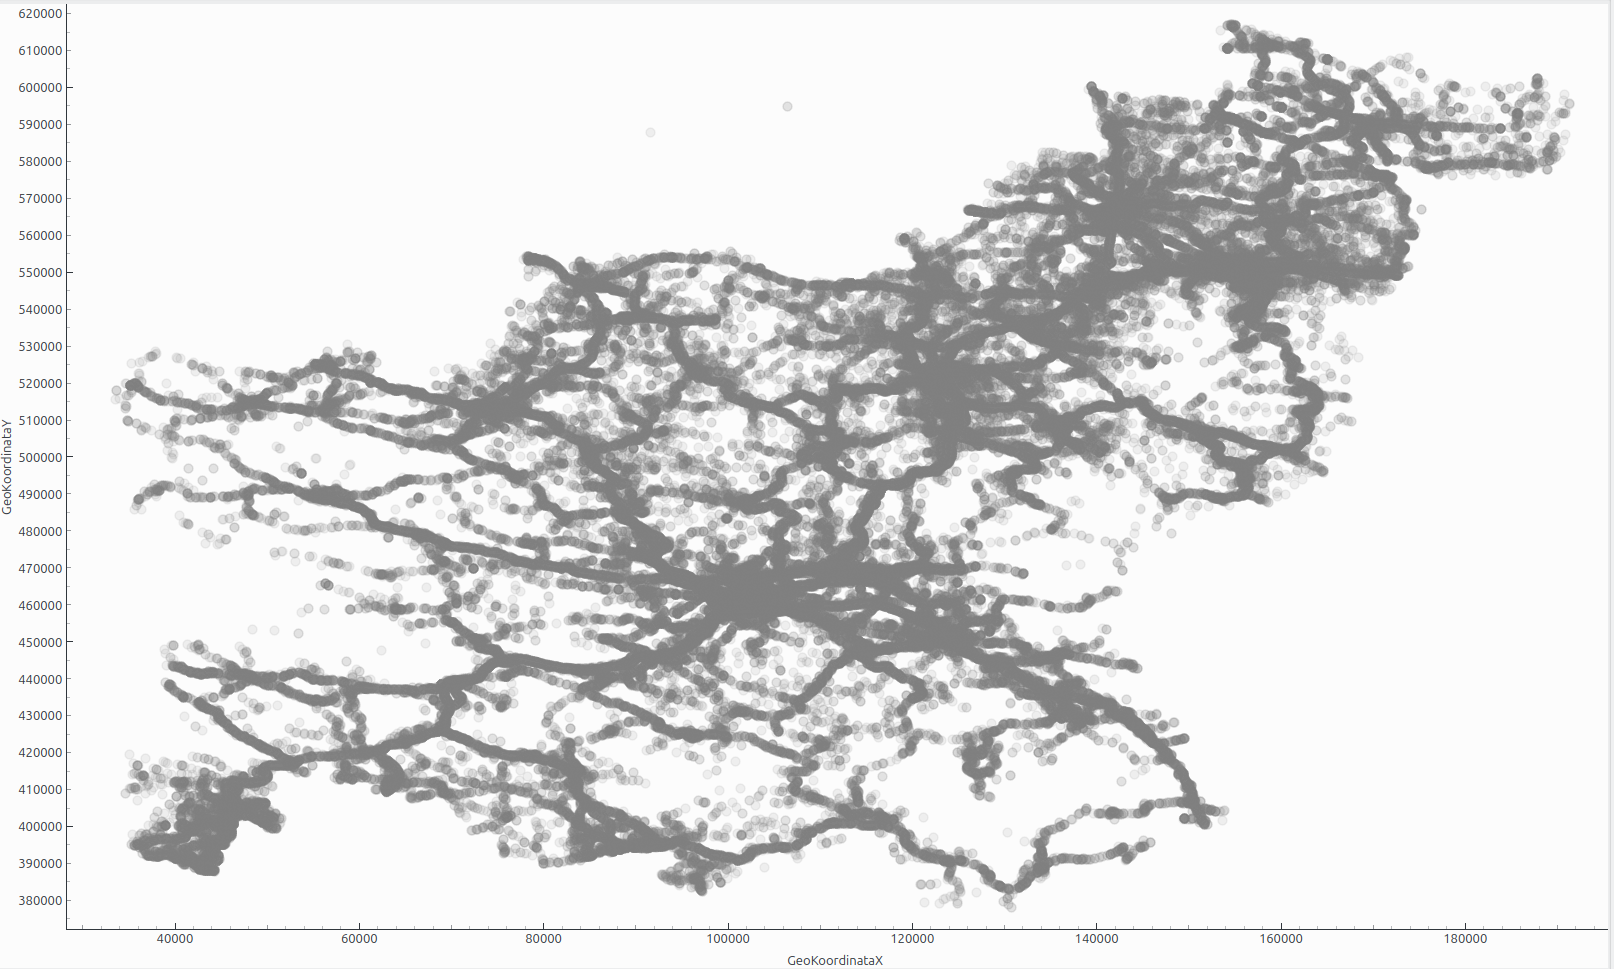

### 1. Katere ure in dnevi v tednu so najnevarnejši?

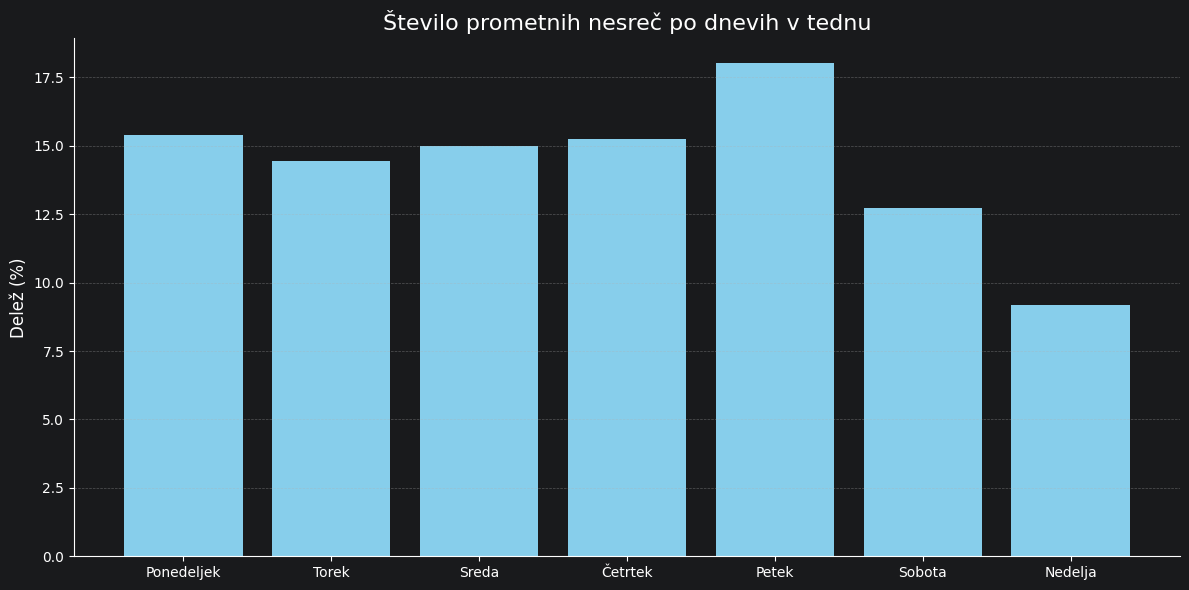

In [8]:
# Reset master_df to its original state (we are changing it in each exercise, so it makes sense to create a clean one)
master_df = pd.read_csv("merged_clean.csv")

master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)

weekday_counts = master_df.groupby(master_df['DatumPN'].dt.dayofweek).size()

weekday_ratio = weekday_counts / weekday_counts.sum() * 100

days = ['Ponedeljek', 'Torek', 'Sreda', 'Četrtek', 'Petek', 'Sobota', 'Nedelja']

plt.figure(figsize=(12, 6))

plt.bar(days, weekday_ratio, width=0.8, color='skyblue', edgecolor='none')

ax = plt.gca()

plt.title('Število prometnih nesreč po dnevih v tednu', fontsize=16)
plt.ylabel('Delež (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

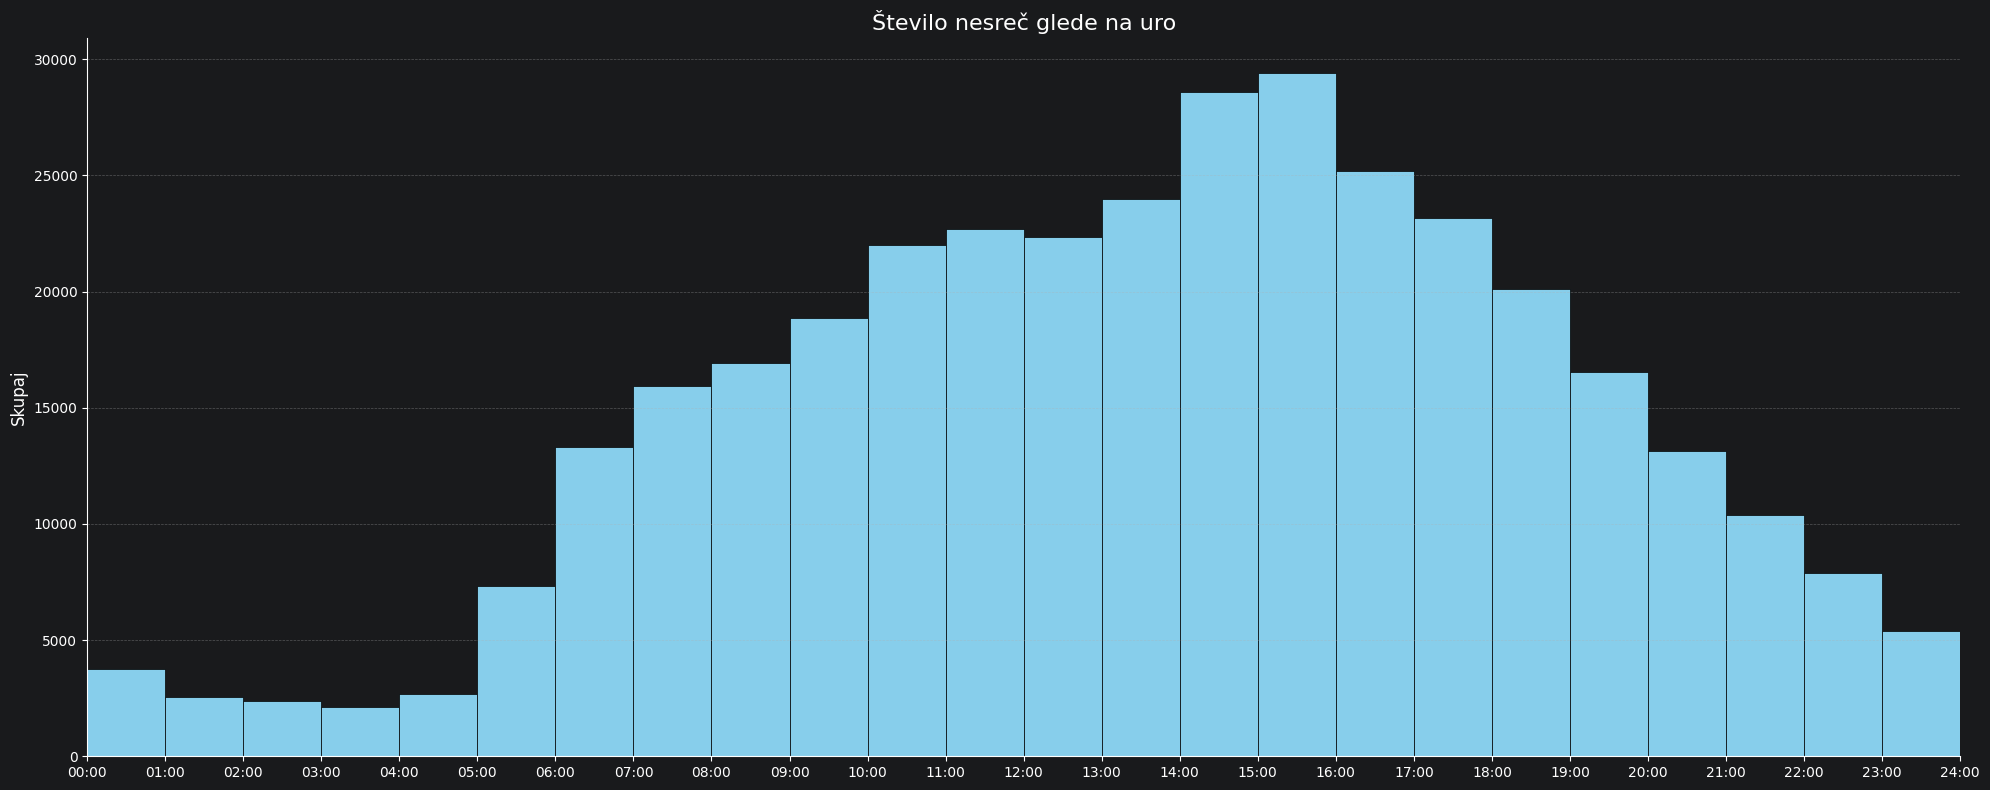

In [9]:
master_df = pd.read_csv("merged_clean.csv") 

master_df['hour'] = master_df['UraPN'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
master_df['hour'] = master_df['hour'].clip(0, 23)

hourly_counts = master_df.groupby('hour').size().reindex(range(24), fill_value=0)

plt.figure(figsize=(20, 8))

plt.bar(hourly_counts.index, hourly_counts.values, width=1.0, color='skyblue', edgecolor='black', linewidth=0.5, align='edge')

ax = plt.gca()
ax.set_xticks(range(0, 25))
ax.set_xticklabels([f"{h:02d}:00" for h in range(25)])
ax.set_xlim(0, 24)

plt.title('Število nesreč glede na uro', fontsize=16)
plt.ylabel('Skupaj', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Iz grafa analize verjetnosti nastankla nesreče glede na dan v tednu lahko razberemo, da je dan z najvišjo verjetnostjo pričakovano petek. Na splošno je delavnik nevarnejši od vikenda, kjer so verjetnosti veliko nižje.

TODO: Dodaj opis za ure

### 2. V kakšnih okoliščinah so najpogostejše nesreče s poškodbami?

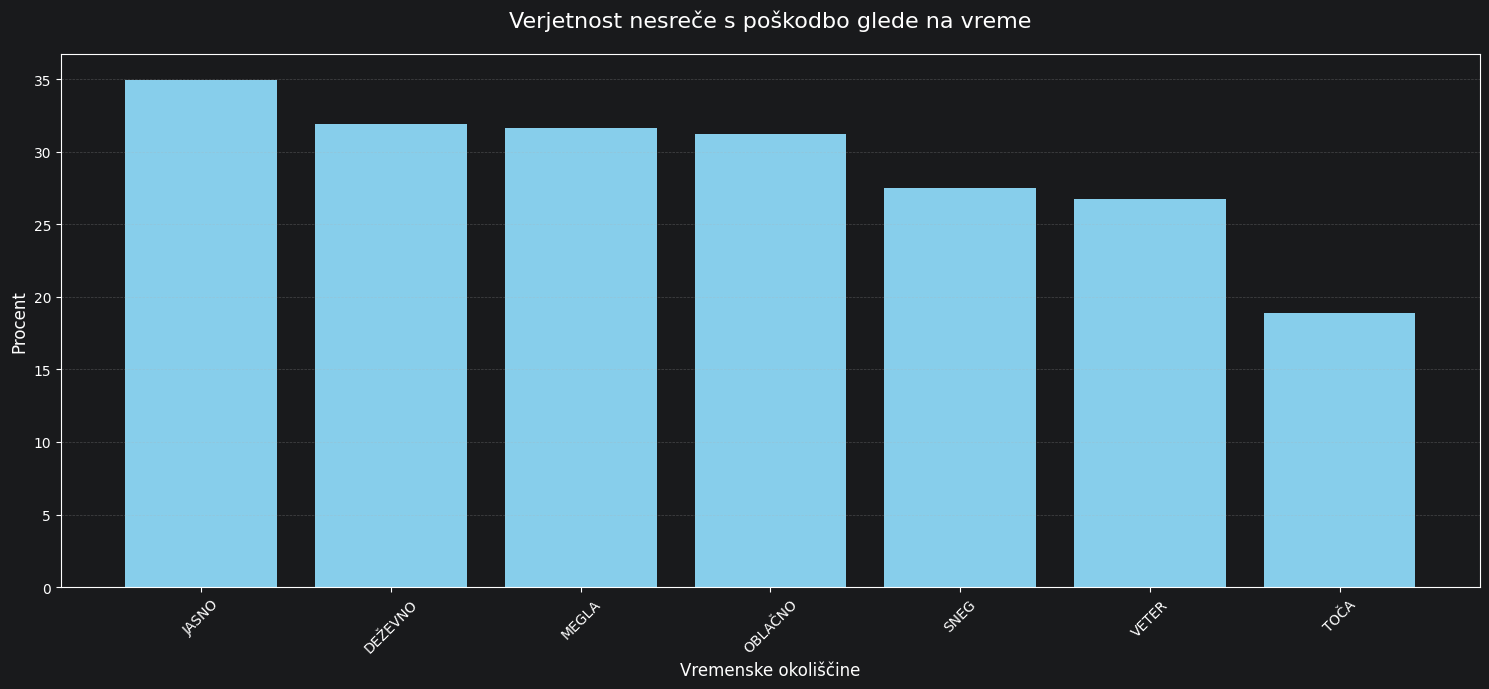

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

master_df = pd.read_csv("merged_clean.csv") 

za_izbris = ['NEZNANO']

master_df = master_df[~master_df['VremenskeOkoliscine'].isin(za_izbris)]

hujse_kategorije = ['S SMRTNIM IZIDOM', 'S HUDO TELESNO POŠKODBO', 'Z LAŽJO TELESNO POŠKODBO'] 

total_per_weather = master_df.groupby('VremenskeOkoliscine')['ID'].nunique()

heavy_accidents_df = master_df[master_df['KlasifikacijaNesrece'].isin(hujse_kategorije)]
heavy_per_weather = heavy_accidents_df.groupby('VremenskeOkoliscine')['ID'].nunique()

normalized_ratios = ((heavy_per_weather / total_per_weather) * 100).fillna(0).sort_values(ascending=False)

plt.figure(figsize=(15, 7))
bars = plt.bar(normalized_ratios.index, normalized_ratios.values, color='skyblue')

plt.title('Verjetnost nesreče s poškodbo glede na vreme', fontsize=16, pad=20)
plt.ylabel('Procent', fontsize=12)
plt.xlabel('Vremenske okoliščine', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Pri analizi smo želeli ugotoviti korelacijo med prometnimi nesrečmi, kjer je vsaj en udeleženec poškodovan in vremenskimi okoliščinami. Ker se velika večina vseh nesreč zgodi ob idealnih pogojih, smo podatke normalizirali. Verjetnost smo izračunali kot razmerje - **število nesreč s poškodbami v nekem vremenu / vse nesreče v nekem vremenu**. Ampak z rezultatom nismo povsem zadovoljni, saj vremenske okoliščine ne nujno vplivajo na cestišče. V podatkih je lahko prisotna nesreča, ki se je zgodila v jasnem vremenu, vendar je na cesti stal sneg, kar bi našo analizo pokvarilo.

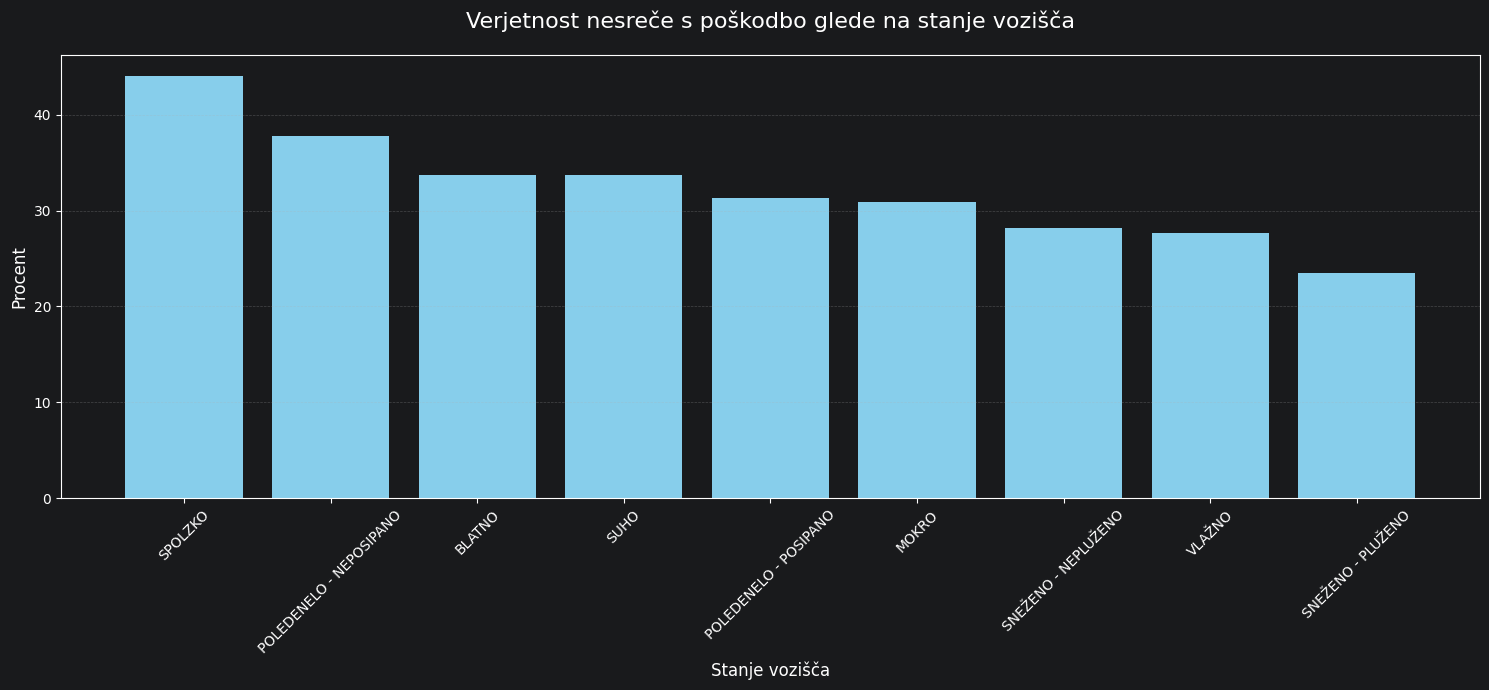

In [11]:

master_df = pd.read_csv("merged_clean.csv") 

za_izbris = ['NEZNANO', 'OSTALO', 'POŠKODOVANO', 'UDARNE JAME', 'KOLESNICE', 'STOJEČA VODA']

master_df = master_df[~master_df['StanjeVozisca'].isin(za_izbris)]

hujse_kategorije = ['S SMRTNIM IZIDOM', 'S HUDO TELESNO POŠKODBO', 'Z LAŽJO TELESNO POŠKODBO'] 

total_per_weather = master_df.groupby('StanjeVozisca')['ID'].nunique()

heavy_accidents_df = master_df[master_df['KlasifikacijaNesrece'].isin(hujse_kategorije)]
heavy_per_weather = heavy_accidents_df.groupby('StanjeVozisca')['ID'].nunique()

normalized_ratios = ((heavy_per_weather / total_per_weather) * 100).fillna(0).sort_values(ascending=False)

plt.figure(figsize=(15, 7))
bars = plt.bar(normalized_ratios.index, normalized_ratios.values, color='skyblue')

plt.title('Verjetnost nesreče s poškodbo glede na stanje vozišča', fontsize=16, pad=20)
plt.ylabel('Procent', fontsize=12)
plt.xlabel('Stanje vozišča', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Zgornji graf nakazuje bolj realističen vpogled v podatke. Iz grafa je razvidno, da se več kot 40 procentov vseh nesreč na spolzkih cestah konča z poškodbo. Opazimo lahko očitno razliko med neposipanim in posipanim cestiščem, ter razliko med pluženim in nepluženim. 

Opazimo lahko tudi, da so vremenske okoliščine in stanja vozišč, ki ji navadno smatramo kot nevarnejša, nižje na lestvicah kot okoliščine, ki jih imamo za idealne. Sklepamo lahko, da so vozniki v zahtevnejših razmerah precej bolj previdni in bistveno počasnejši, kar zmanjšuje silovitost trčenj, čeprav je število manjših nesreč (npr. zdrsov) pri takih okoliščinah morda večje.

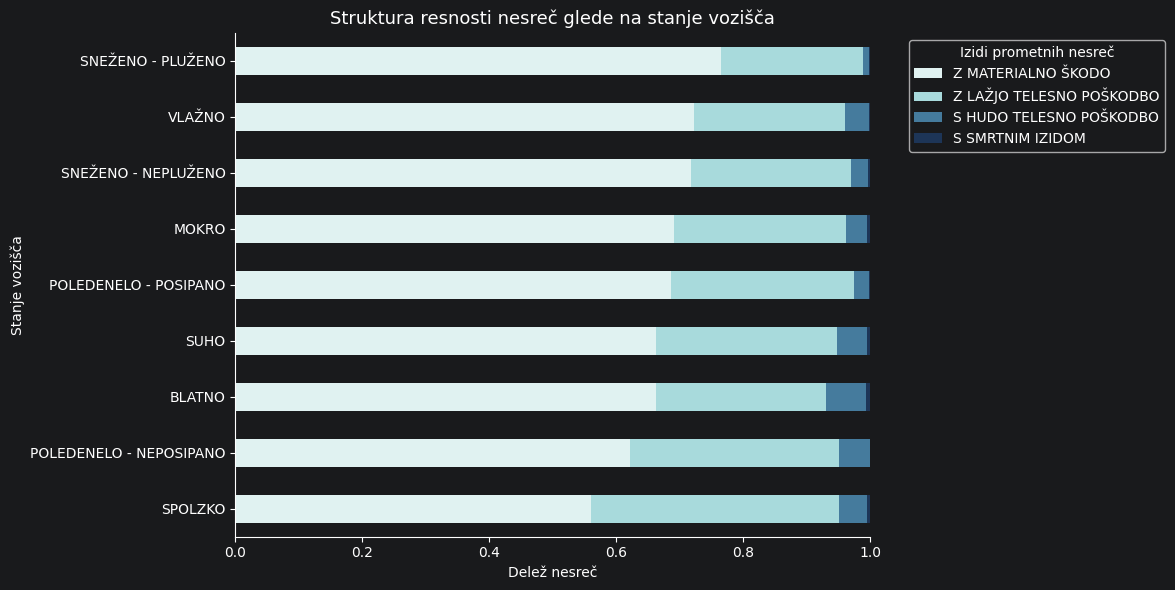

In [12]:
kategorije_resnosti = {
    'Z MATERIALNO ŠKODO': 1,
    'Z LAŽJO TELESNO POŠKODBO': 2,
    'S HUDO TELESNO POŠKODBO': 3,
    'S SMRTNIM IZIDOM': 4
}

master_df['Resnost_Rank'] = master_df['KlasifikacijaNesrece'].map(kategorije_resnosti)

df_nesrece = master_df.sort_values(['ID', 'Resnost_Rank'], ascending=[True, False]).drop_duplicates('ID')

summary = df_nesrece.groupby(['StanjeVozisca', 'KlasifikacijaNesrece']).size().unstack().fillna(0)

vrstni_red_izidov = [
    'Z MATERIALNO ŠKODO', 
    'Z LAŽJO TELESNO POŠKODBO', 
    'S HUDO TELESNO POŠKODBO', 
    'S SMRTNIM IZIDOM'
]
obstojeci_stolpci = [c for c in vrstni_red_izidov if c in summary.columns]
summary = summary[obstojeci_stolpci]

summary_pct = summary.div(summary.sum(axis=1), axis=0)

if 'S HUDO TELESNO POŠKODBO' in summary_pct.columns:
    col_sort = 'Z MATERIALNO ŠKODO'
    summary_pct = summary_pct.sort_values(by=col_sort, ascending=True)

my_colors = ['#E0F2F1', '#A8DADC', '#457B9D', '#1D3557']
ax = summary_pct.plot(kind='barh', stacked=True, figsize=(12, 6), color=my_colors[:len(summary_pct.columns)])

plt.title('Struktura resnosti nesreč glede na stanje vozišča', fontsize=13)
plt.xlabel('Delež nesreč')
plt.ylabel('Stanje vozišča')
plt.legend(title='Izidi prometnih nesreč', bbox_to_anchor=(1.05, 1), loc='upper left')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Predpostavko lahko podkrepimo z zgornjim grafom strukture resnosti nesreč. Opazimo lahko, da pri snežnem in mokrem vozišču prevladujejo nesreče z materialno škodo. 

Zanimiv je tudi podatek, da je verjetnost nastanka nesreče s hujšimi poškodbami ali smrtjo najvišja na blatnih cestah. Velja omeniti, da gre tukaj najpogosteje za makadamske ceste izven naselja, na katere povprečen voznik ne zahaja pogosto.

### 3. Letni trend vožnje pod vplivom alkohola med mladimi vozniki.

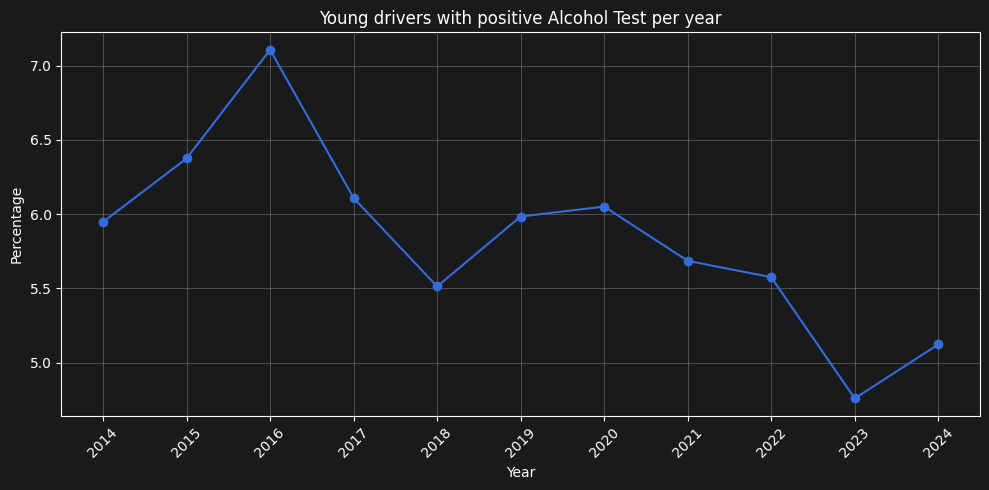

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

master_df = pd.read_csv("merged_clean.csv")
master_df['Starost'] = master_df['Starost'].replace(" ", None)
master_df['Starost'] = pd.to_numeric(master_df['Starost'], errors='coerce')
master_df['VrednostAlkotesta'] = pd.to_numeric(master_df['VrednostAlkotesta'], errors='coerce')
master_df['DatumPN'] = pd.to_datetime(master_df['DatumPN'], dayfirst=True)

young_drivers_alcohol = master_df[(master_df['Starost'] > 12) & (master_df['Starost'] < 30) & (master_df['VrednostAlkotesta'] > 0)]
young_drivers_all = master_df[(master_df['Starost'] > 12) & (master_df['Starost'] < 30)]

alcohol_yearly = young_drivers_alcohol.groupby(young_drivers_alcohol['DatumPN'].dt.year).size()
all_yearly = young_drivers_all.groupby(young_drivers_all['DatumPN'].dt.year).size()

ratio = (alcohol_yearly / all_yearly) * 100

plt.figure(figsize=(10, 5))
plt.plot(ratio.index, ratio.values, marker="o")
plt.title('Young drivers with positive Alcohol Test per year')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.xticks(ratio.index, rotation= 45)
plt.grid(True)
plt.tight_layout()
plt.show()

Če upoštevamo, da je bilo leto 2020 odstopajoče zaradi COVID-19, lahko rečemo, da med mladimi vozniki vožnja pod vplivom alkohola upada, pri čemer so prisotna le manjša odstopanja.

### 4. Identifikacija žarišč

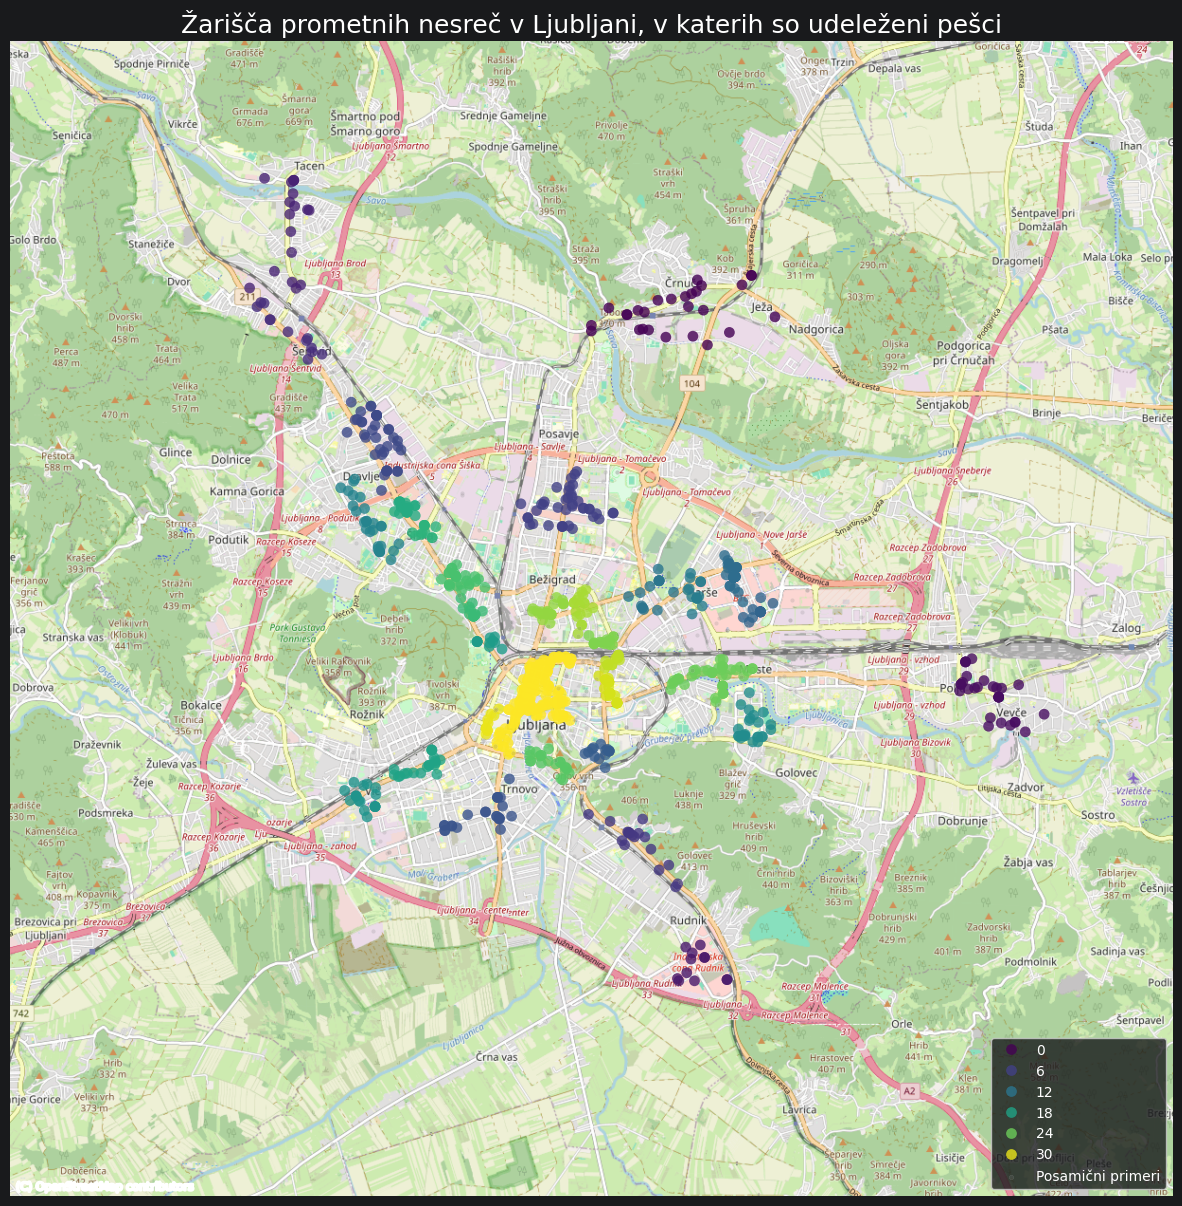

In [14]:
import hdbscan
import seaborn as sns
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

target_attribute = "VrstaUdelezenca"
target_value = "PEŠEC"
min_cluster_size = 10 

df_target = master_df[
    (master_df['GeoKoordinataX'] >= 95000) & (master_df['GeoKoordinataX'] <= 110000) &
    (master_df['GeoKoordinataY'] >= 455000) & (master_df['GeoKoordinataY'] <= 470000) &
    (master_df[target_attribute] == target_value)
].drop_duplicates('ZaporednaStevilkaPN').copy()

slo_crs = "+proj=tmerc +lat_0=0 +lon_0=15 +k=0.9999 +x_0=500000 +y_0=-5000000 +ellps=bessel +towgs84=409.545,72.164,486.887,3.08595,5.4691,11.02028,17.91922 +units=m +no_defs"
transformer = Transformer.from_crs(slo_crs, "epsg:3857", always_xy=True)

transformer = Transformer.from_crs(slo_crs, "epsg:3857", always_xy=True)


df_target['coords_x'], df_target['coords_y'] = transformer.transform(
    df_target['GeoKoordinataY'].values, 
    df_target['GeoKoordinataX'].values
)

OFFSET_X = -50  
OFFSET_Y = -650

df_target['coords_x'] = df_target['coords_x'] + OFFSET_X
df_target['coords_y'] = df_target['coords_y'] + OFFSET_Y

if len(df_target) > 10:
    clusterer = hdbscan.HDBSCAN(min_cluster_size= min_cluster_size, min_samples=5)
    df_target['Cluster'] = clusterer.fit_predict(df_target[['coords_x', 'coords_y']])
else:
    df_target['Cluster'] = -1

plt.figure(figsize=(15, 15))
ax = plt.gca()

sns.scatterplot(
    data=df_target[df_target.Cluster != -1], 
    x='coords_x', y='coords_y', 
    hue='Cluster', palette='viridis', s=60, alpha=0.8, ax=ax, edgecolor='none'
)

sns.scatterplot(
    data=df_target[df_target.Cluster == -1], 
    x='coords_x', y='coords_y', 
    color='gray', s=10, alpha=0.2, ax=ax, label='Posamični primeri'
)

try:
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=13)
except Exception as e:
    print(f"Težava pri nalaganju zemljevida: {e}")

ax.set_axis_off()
plt.title(f'Žarišča prometnih nesreč v Ljubljani, v katerih so udeleženi pešci', fontsize=18)
plt.show()

Tukaj se osredotočimo na ranljivejše udeležence v prometu - pešče. Na podalagi koordinat v podatkih lahko z algoritmom HDBSCAN na zgornjem zemljevidu Ljubljane prikažemo vroče točke, kjer so v prometne nesreče najpogosteje udeleženi tudi pešči. Vidimo, da se te geruče nahajajo na conah z večjim številom pešcev, kot je naprimer center, glavne vpadnice in okolica univerzitetnega kliničnega centra.

In [15]:
#with pd.option_context('display.max_rows', None):
#    print(master_df["VrstaVozisca"].value_counts(dropna=False))

### 5. So nesreče zunaj mest resnejše?

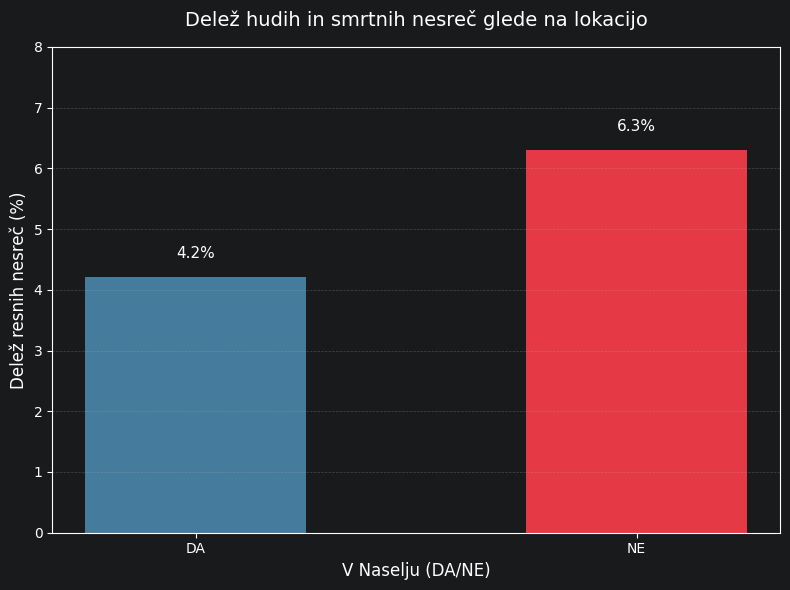


Znotraj naselja: 4.22%
Izven naselja:   6.31%


In [23]:
master_df = pd.read_csv("merged_clean.csv")


resne_kategorije = [
    'S SMRTNIM IZIDOM',
    'S HUDO TELESNO POŠKODBO'
]

#Since multiple people are involved in accidents,we have to deduplicate

df_unique_accidents = master_df.drop_duplicates('ID').copy()

df_unique_accidents['JeResna'] = (
    df_unique_accidents['KlasifikacijaNesrece']
    .isin(resne_kategorije)
)

# Remove unknown values
location_df = df_unique_accidents[
    df_unique_accidents['VNaselju'] != 'NEZNANO'
].copy()

# Calculate percentages
location_ratio = (
    location_df
    .groupby('VNaselju')['JeResna']
    .mean() * 100
)

# Plot
plt.figure(figsize=(8, 6))

bars = plt.bar(
    location_ratio.index,
    location_ratio.values,
    color=['#457B9D', '#E63946'],
    width=0.5
)

plt.title(
    'Delež hudih in smrtnih nesreč glede na lokacijo',
    fontsize=14,
    pad=15
)
plt.ylim(0, 8)

plt.ylabel('Delež resnih nesreč (%)', fontsize=12)
plt.xlabel("V Naselju (DA/NE)",fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# Print percentages
print(f"\nZnotraj naselja: {location_ratio.get('DA', 0):.2f}%")
print(f"Izven naselja:   {location_ratio.get('NE', 0):.2f}%")

Zdaj so odstotki majhni (to je preprosto zato, ker so hude nesreče (s smrtjo ali hudimi telesnimi poškodbami)) redke. Vendar se ne dajte zavesti, razlika je dejansko 1,5-kratna. Če niste prepričani, naredimo nekaj statistike.

In [28]:
from scipy.stats import chi2_contingency

print("\n--- Chi-Square Test ---")

location_table = pd.crosstab(
    location_df['VNaselju'],
    location_df['JeResna']
)
print(location_table)
print("\n")

chi2, p, dof, expected = chi2_contingency(location_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.6f}")


if p < 0.05:
    print("Razlika je statistično značilna.")
else:
    print("Razlika NI statistično značilna.")


--- Chi-Square Test ---
JeResna    False  True 
VNaselju               
DA        132315   5825
NE         57925   3900


Chi-square statistic: 403.302
p-value: 0.000000
Razlika je statistično značilna.


Vau, p je tako majhen, da ni pravilno oblikovan.\
Kot lahko vidimo, se več nesreč zgodi v naseljih kot zunaj njih, vendar je odstotek hudih nesreč zunaj višji kot znotraj in s tako nizko vrednostjo p lahko sklepamo, da so nesreče zunaj naselij hujše.

### 6. So nesreče ponoči resnejše?

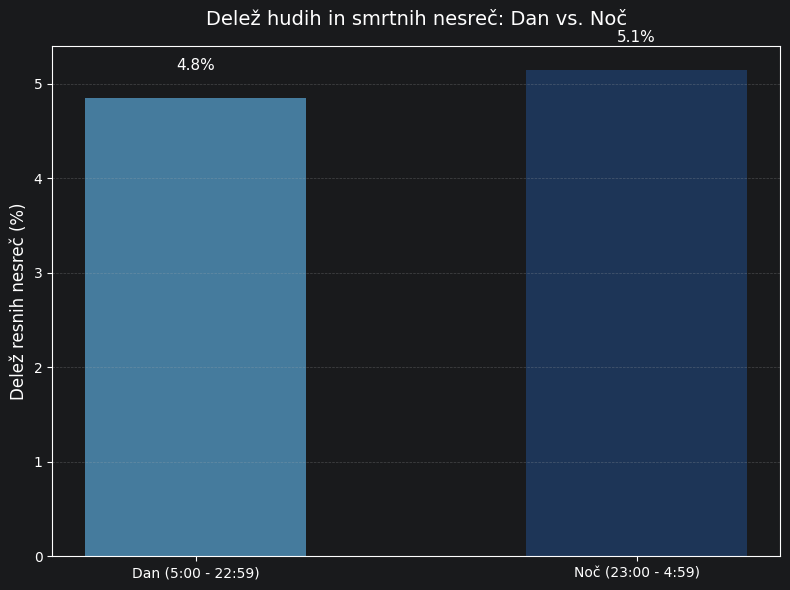


Dan (5:00-22:59):  4.84%
Noč (23:00-4:59): 5.14%


In [34]:
master_df = pd.read_csv("merged_clean.csv")
resne_kategorije = [
    'S SMRTNIM IZIDOM',
    'S HUDO TELESNO POŠKODBO'
]

df_unique_accidents = master_df.drop_duplicates('ID').copy()
df_unique_accidents['JeResna'] = (
    df_unique_accidents['KlasifikacijaNesrece']
    .isin(resne_kategorije)
)

df_unique_accidents['hour'] = (
    df_unique_accidents['UraPN']
    .astype(str)
    .str.extract(r'(\d{1,2})')[0]
)

# Convert to numeric
df_unique_accidents['hour'] = pd.to_numeric(
    df_unique_accidents['hour'],
    errors='coerce'
)

# Remove invalid hours
df_unique_accidents['hour'] = (
    df_unique_accidents['hour']
    .fillna(0)
    .clip(0, 23)
    .astype(int)
)

# Night definition: 23:00 - 4:59
df_unique_accidents['is_night'] = (
    (df_unique_accidents['hour'] >= 23) |
    (df_unique_accidents['hour'] <= 4)
)
night_ratio = (
    df_unique_accidents[
        df_unique_accidents['is_night']
    ]['JeResna'].mean() * 100
)

day_ratio = (
    df_unique_accidents[
        ~df_unique_accidents['is_night']
    ]['JeResna'].mean() * 100
)

# Plot
plt.figure(figsize=(8, 6))

bars = plt.bar(
    ['Dan (5:00 - 22:59)', 'Noč (23:00 - 4:59)'],
    [day_ratio, night_ratio],
    color=['#457B9D', '#1D3557'],
    width=0.5
)

plt.title(
    'Delež hudih in smrtnih nesreč: Dan vs. Noč',
    fontsize=14,
    pad=15
)

plt.ylabel('Delež resnih nesreč (%)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

# Labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

print(f"\nDan (5:00-22:59):  {day_ratio:.2f}%")
print(f"Noč (23:00-4:59): {night_ratio:.2f}%")

Kot lahko vidimo, obstaja majhna razlika, vendar bi lahko bila statistično pomembna. Preizkusiti bi morali s χ² testom.

In [35]:
print("\n--- Chi-Square Test ---")

night_table = pd.crosstab(
    df_unique_accidents['is_night'],
    df_unique_accidents['JeResna']
)
print(night_table)
print("\n")

chi2, p, dof, expected = chi2_contingency(night_table)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p:.6f}")

if p < 0.05:
    print("Razlika je statistično značilna.")
else:
    print("Razlika NI statistično značilna.")


--- Chi-Square Test ---
JeResna    False  True 
is_night               
False     178456   9086
True       11784    639


Chi-square statistic: 2.186
p-value: 0.139298
Razlika NI statistično značilna.


In ni tako. Vendar pa je zanimivo opažanje, da je podnevi 10-krat več nesreč kot ponoči. Torej so nočne nesreče na splošno redkejše, njihova stopnja resnosti pa je le nekoliko višja kot pri dnevnih nesrečah. Razlika ni bila statistično pomembna.

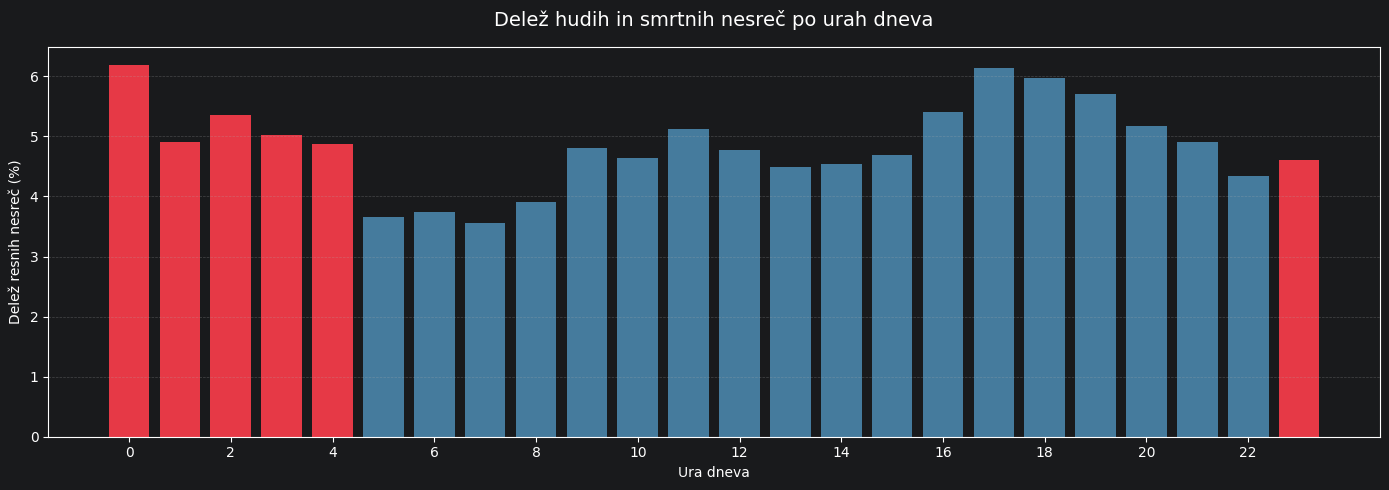

In [32]:
hourly_severe = []

for hour in range(24):

    hour_data = df_unique_accidents[
        df_unique_accidents['hour'] == hour
    ]

    severe_pct = (
        hour_data['JeResna'].mean() * 100
        if len(hour_data) > 0
        else 0
    )

    hourly_severe.append(severe_pct)

plt.figure(figsize=(14, 5))

colors = [
    '#E63946' if (h >= 23 or h <= 4)
    else '#457B9D'
    for h in range(24)
]

plt.bar(
    range(24),
    hourly_severe,
    color=colors
)

plt.title(
    'Delež hudih in smrtnih nesreč po urah dneva',
    fontsize=14,
    pad=15
)

plt.xlabel('Ura dneva')
plt.ylabel('Delež resnih nesreč (%)')

plt.xticks(range(0, 24, 2))



plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Da, razlike so zelo majhne, ​​zato ta analiza ugotavlja, da je resnost nesreč podnevi in ​​ponoči podobna, zato ne moremo reči, da so nesreče ponoči hujše.